## Forcing modes in 2D: `"momentum"` vs `"elsasser"`

jax_rmhd's stochastic forcing (`params.forcing=True`) is an Ornstein-Uhlenbeck (OU)
process: a smoothly decorrelating random pattern confined to a shell of large-scale
perpendicular wavenumbers (`fshell`), rescaled every step so that it injects energy at a
fixed target rate. `forcing_mode` selects *where* that power goes:

- **`"momentum"`** -- the OU force drives the stream function $\phi$ only: external
  mechanical stirring of the flow. One OU pattern, so `forcing_state` has leading axis
  `n_ou = 1`, and the target injection rate is `forcing_power`.
- **`"elsasser"`** -- two *independent* OU patterns force the Elsasser potentials
  $z^\pm = \phi \pm \psi$, each at its own target rate
  `forcing_power_elsasser = (eps_plus, eps_minus)` (`n_ou = 2`). Since
  $f_\phi = (f^+ + f^-)/2$ and $f_\psi = (f^+ - f^-)/2$, this injects both kinetic *and*
  magnetic energy, and the split $\varepsilon^+$ vs $\varepsilon^-$ controls the
  injection of cross-helicity: $dH_c/dt = \varepsilon^+ - \varepsilon^-$, so equal
  powers inject none on average.

This notebook runs the two modes side by side from identical quiescent initial
conditions (same grid, same dissipation, same OU seed) and demonstrates:

1. a documented gotcha: in 2D, momentum forcing from rest is **pure hydrodynamics** --
   $\psi$ stays *exactly* zero;
2. the injection-power bookkeeping: measured $dE/dt$ vs the target rate vs the
   spectrally computed dissipation, all on the shared `perp_*` normalization convention.


In [1]:
#imports
import os, shutil
import numpy as np
import jax
import jax.numpy as jnp
import jax.numpy.fft as ft
import matplotlib.pyplot as plt

import jax_rmhd as jr
import jax_rmhd.snapshot_io as sn
import jax_rmhd.diagnostics as diag
#lower-level helper reused for energy diagnostics in the same physical units that
#forcing_power is defined in (see physics/shared_physics.py)
from jax_rmhd.physics import shared_physics

jax is using 64bit precision.


In [2]:
#grid + physical parameters, shared by both runs
nx = ny = 128
Lx = Ly = 2.0 * jnp.pi
visc = res = 1e-9          #hyperviscosity / hyperresistivity
hyper = 3
cfl_safety = 0.5
t_snap = 0.5
t_end = 15.0
nsnap = 1000

#forcing parameters shared by both runs
forcing_tau = 1.0          #O-U decorrelation time of the forcing pattern
fshell = (1, 3)            #force the shell 1 <= |k_perp|/dk < 3 (large scales)
forcing_seed = 234         #same seed for both runs (the two modes consume the RNG
                           #stream differently, so the patterns aren't pairwise equal)
forcing_scale_max = 1.0    #cap on the power-normalization scale factor (see below)

base_path = "data/forcing-modes-2D/"
#start fresh on re-run: snapshot indices continue from whatever is on disk, and
#params.json is sticky (identical re-save is a no-op, a differing record is a hard error)
if os.path.isdir(base_path):
    shutil.rmtree(base_path)

def make_params(**mode_kwargs):
    return jr.Parameters(nx=nx, ny=ny, Lx=Lx, Ly=Ly, diss=(visc, res), hyper=hyper,
                         cfl_safety=cfl_safety, dims=2, forcing=True,
                         forcing_tau=forcing_tau, fshell=fshell,
                         forcing_seed=forcing_seed, forcing_scale_max=forcing_scale_max,
                         **mode_kwargs)

def zero_init(x, y):
    #quiescent start: the forcing spins turbulence up from rest
    return jnp.zeros((2,) + jnp.broadcast_shapes(x.shape, y.shape))

### Run both modes

Each run gets its own snapshot directory, with `params.save` recording the configuration
next to the data. The elsasser powers are chosen so both runs target the same *total*
injection rate ($0.3$; derivation below).

In [3]:
def run(mode_kwargs, snap_path):
    params = make_params(**mode_kwargs)
    params.save(snap_path)  #records constructor args + precision to snap_path/params.json
    mngr = jr.snapshot_manager_setup(params=params, snap_path=snap_path, nsnap=nsnap)
    kgrid = jr.setup_kgrids(params)  #one kgrid per Parameters object, never shared
    state = jr.initialize(zero_init, params)
    nblock = jr.estimate_good_nblock(state, kgrid, params, t_snap, t_end, nblock_min=10)
    #buffer donation: `state` is consumed by simulate_scan -- use the returned state
    end_state = jr.simulate_scan(state, kgrid, params, nblock, t_snap=t_snap,
                                 t_end=t_end, mngr=mngr, save=True, print_every=10)
    return params, kgrid, end_state

path_m = base_path + "momentum/"
path_e = base_path + "elsasser/"

params_m, kgrid_m, end_m = run(dict(forcing_mode="momentum",
                                    forcing_power=0.3), path_m)
params_e, kgrid_e, end_e = run(dict(forcing_mode="elsasser",
                                    forcing_power_elsasser=(0.15, 0.15)), path_e)

Saving initial state as snapshot 0 at t = 0.0
Saving snapshot as snapshot 1 at t = 0.5639170589738295
Saving snapshot as snapshot 2 at t = 1.0955873401072338
1.2236897114731058
Saving snapshot as snapshot 3 at t = 1.632431189913448
1.7984085425494796
Saving snapshot as snapshot 4 at t = 2.184166159597864
2.3551995782538
Saving snapshot as snapshot 5 at t = 2.692167445511116
2.889950640173404
Saving snapshot as snapshot 6 at t = 3.2043746387243512
3.335618040092199
Saving snapshot as snapshot 7 at t = 3.7447163603689253
3.795511565575646
Saving snapshot as snapshot 8 at t = 4.3006879034413945
4.4266290609986765
Saving snapshot as snapshot 9 at t = 4.84786588019338
4.949258351257118
Saving snapshot as snapshot 10 at t = 5.368209804359749
5.48357235628894
Saving snapshot as snapshot 11 at t = 5.886367585858967
6.051908089466306
Saving snapshot as snapshot 12 at t = 6.404054149046045
6.544604466158456
Saving snapshot as snapshot 13 at t = 6.923585946208151
7.026758879549063
Saving snapshot

### The gotcha: 2D momentum forcing from rest is pure hydro

In 2D the flux-function equation is
$\partial_t \psi = -\{\phi,\psi\} + \text{resistive dissipation} + f_\psi$.
Momentum mode has $f_\psi = 0$, and every remaining source of $\psi$ is proportional to
$\psi$ itself: starting from $\psi = 0$, the bracket $\{\phi,\psi\}$, the dissipation,
and the (absent in 2D) $\partial_z$ coupling all evaluate to *exactly* zero in floating
point, every sub-stage, every step. So $\psi$ stays **bitwise zero** -- not small, not
roundoff, zero -- and the "MHD" run is really 2D Navier-Stokes being stirred. (In 3D the
linear term $\partial_z\phi$ seeds $\psi$, so this is a purely 2D trap.) For actual 2D
MHD turbulence from a quiescent start, use `"elsasser"`.

In [4]:
max_abs_psik_m = float(jnp.max(jnp.abs(end_m.fields[1])))
max_abs_psik_e = float(jnp.max(jnp.abs(end_e.fields[1])))
print(f"momentum run: max |psi_k| at t_end = {max_abs_psik_m}")
print(f"elsasser run: max |psi_k| at t_end = {max_abs_psik_e}")

assert max_abs_psik_m == 0.0, "2D momentum forcing from rest should leave psi EXACTLY zero"
print()
print("PASS: psi is exactly (bitwise) zero in the 2D momentum-forced run")

momentum run: max |psi_k| at t_end = 0.0
elsasser run: max |psi_k| at t_end = 8058.984592744266

PASS: psi is exactly (bitwise) zero in the 2D momentum-forced run


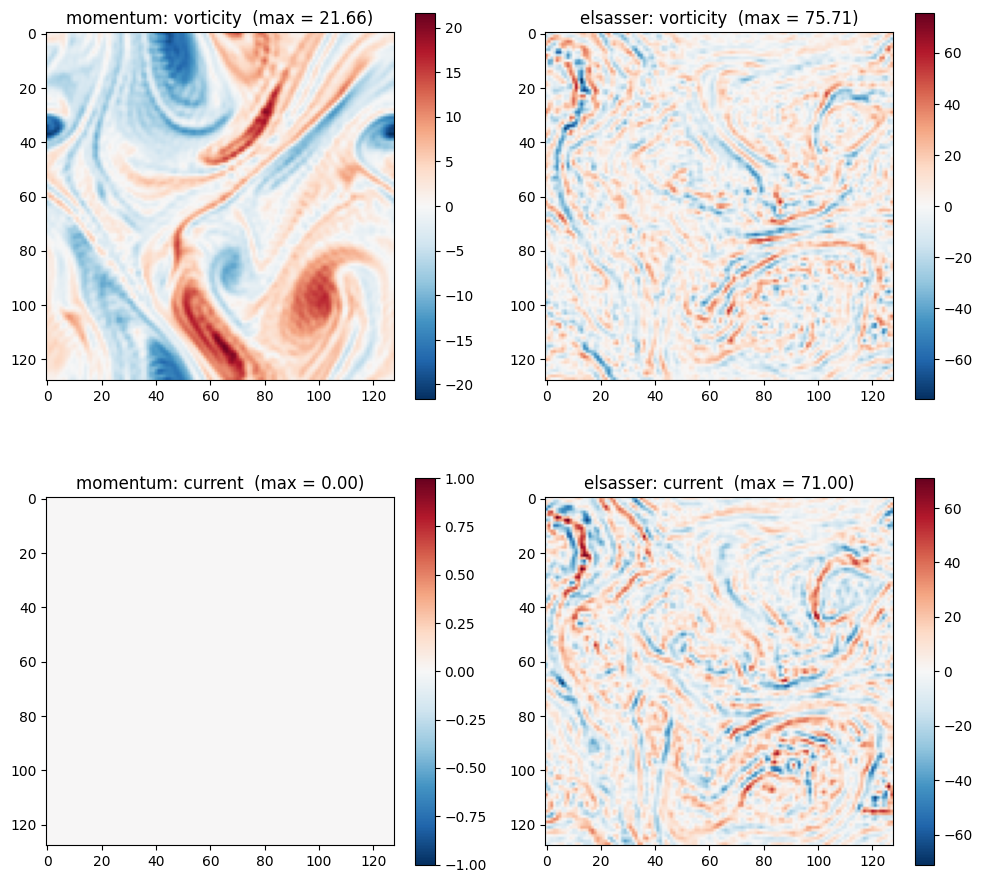

In [5]:
#vorticity (lap phi) and parallel current (lap psi) at the end of each run
fig, axes = plt.subplots(2, 2, figsize=(10, 9.5))
for col, (kgrid, end, label) in enumerate([(kgrid_m, end_m, "momentum"),
                                           (kgrid_e, end_e, "elsasser")]):
    vort = ft.irfft2(-kgrid.ksq * end.fields[0, 0])
    jpar = ft.irfft2(-kgrid.ksq * end.fields[1, 0])
    for row, (f, name) in enumerate([(vort, "vorticity"), (jpar, "current")]):
        ax = axes[row, col]
        fmax = float(jnp.max(jnp.abs(f)))
        scale = fmax if fmax > 0 else 1.0  #the momentum run's current is all zeros
        im = ax.imshow(f, cmap="RdBu_r", vmin=-scale, vmax=scale)
        ax.set_title(f"{label}: {name}  (max = {fmax:.2f})")
        fig.colorbar(im, ax=ax, shrink=0.85)
plt.tight_layout()

### Energy time series from the snapshots

Exactly as in `forced-turbulence-2D.ipynb`:
$E_{\rm kin} = \tfrac12\,$`perp_inner_product(phik, phik, ...)`,
$E_{\rm mag} = \tfrac12\,$`perp_inner_product(psik, psik, ...)`.
We also compute the spectral dissipation power per snapshot (`diss_power` below) for the
bookkeeping plot that follows.

In [6]:
def diss_power(snap, kgrid, params):
    #dE/dt drained by the hyperdissipation, mode by mode, on the shared perp_* convention:
    #each field obeys d(f_k)/dt|_diss = -diss[i]*ksq**hyper * f_k (applied as an
    #integrating factor in timestepping.py), and the energy in mode k is
    #E_k = 0.5*ksq*|f_k|^2 * yfac / (nz*(nx*ny)**2), so P_diss = sum_k 2*diss[i]*ksq**hyper * E_k
    norm = float(params.nz) * float(params.nx * params.ny)**2
    P = 0.0
    for i in range(2):
        P += float(jnp.sum(2.0 * params.diss[i] * kgrid.ksq**params.hyper
                           * 0.5 * kgrid.ksq * jnp.abs(snap.fields[i])**2
                           * kgrid.yfac) / norm)
    return P

def load_series(snap_path, params, kgrid):
    ts, E_kin, E_mag, P_diss = [], [], [], []
    for isnap in sn.get_saved_steps(snap_path):
        snap = sn.load_snapshot(isnap, snap_path, params)
        phik, psik = snap.fields[0], snap.fields[1]
        ts.append(float(snap.t))
        E_kin.append(float(0.5 * shared_physics.perp_inner_product(phik, phik, kgrid, params)))
        E_mag.append(float(0.5 * shared_physics.perp_inner_product(psik, psik, kgrid, params)))
        P_diss.append(diss_power(snap, kgrid, params))
    return (np.array(ts), np.array(E_kin), np.array(E_mag), np.array(P_diss))

series_m = load_series(path_m, params_m, kgrid_m)
series_e = load_series(path_e, params_e, kgrid_e)

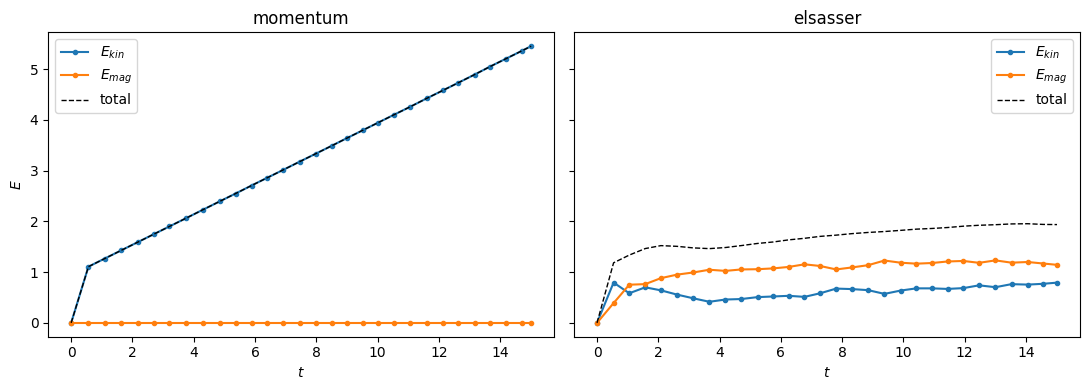

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (ts, E_kin, E_mag, _), label in zip(axes, [series_m, series_e],
                                            ["momentum", "elsasser"]):
    ax.plot(ts, E_kin, marker='o', markersize=3, label=r'$E_{kin}$')
    ax.plot(ts, E_mag, marker='o', markersize=3, label=r'$E_{mag}$')
    ax.plot(ts, E_kin + E_mag, 'k--', linewidth=1, label='total')
    ax.set_xlabel(r'$t$')
    ax.set_title(label)
    ax.legend()
axes[0].set_ylabel(r'$E$')
plt.tight_layout()

### Injection-power bookkeeping

All energy-like numbers in jax_rmhd share one normalization convention (the rfft2
$k_y$-doubling `kgrid.yfac`, divided by $n_z (n_x n_y)^2$ -- see
`shared_physics._perp_reduce`), and the derivations below live entirely on it. Write
$\mathrm{pip}(a,b)$ for `perp_inner_product(a_k, b_k, kgrid, params)`
$= \langle \nabla_\perp a \cdot \nabla_\perp b \rangle$; the energies above are
$E_{\rm kin} = \tfrac12\mathrm{pip}(\phi,\phi)$ and
$E_{\rm mag} = \tfrac12\mathrm{pip}(\psi,\psi)$.

**Momentum mode.** The force enters as $\partial_t\phi \supset f_\phi = s\,\hat f$ with
$\hat f$ the raw OU pattern, injecting kinetic energy at rate
$\mathrm{pip}(\phi, f_\phi) = s\,P$ where $P \equiv \mathrm{pip}(\phi,\hat f)$. The
scale is $s = \mathrm{clip}(\varepsilon/P,\ \pm s_{\max})$
(`shared_physics.safe_scale`, with $\varepsilon =$ `forcing_power` and $s_{\max} =$
`forcing_scale_max`; see `rmhd._forcing_scale_from`), so away from the cap the injection
is exactly $dE_{\rm kin}/dt = \varepsilon = 0.3$.

**Elsasser mode.** Two independent patterns are normalized against the Elsasser fields:
$\mathrm{pip}(z^\pm, f^\pm) = 2\varepsilon^\pm$ (the factor 2 in
`rmhd._forcing_scale_from`). Substituting $f_\phi = (f^+ + f^-)/2$
and $f_\psi = (f^+ - f^-)/2$, bilinearity of $\mathrm{pip}$ gives

$$\frac{dE}{dt} = \mathrm{pip}(\phi, f_\phi) + \mathrm{pip}(\psi, f_\psi)
= \tfrac12\left[\mathrm{pip}(z^+, f^+) + \mathrm{pip}(z^-, f^-)\right]
= \varepsilon^+ + \varepsilon^-,$$

so with `forcing_power_elsasser = (0.15, 0.15)` both runs target the same total
$dE/dt = 0.3$.

**Dissipation.** The hyperdissipation drains energy at
$P_{\rm diss} = \sum_k 2\nu k_\perp^{2h} E_k$ per field
($\nu =$ `diss[i]`, $h =$ `hyper`, mode energy
$E_k = \tfrac12 k_\perp^2 |f_k|^2\,\mathrm{yfac}/(n_z (n_x n_y)^2)$) -- the same
convention again, so the balance $dE/dt = P_{\rm inj} - P_{\rm diss}$ is directly
comparable term by term.

Two regimes to look for below:

- **Spin-up.** From a quiescent start $P = \mathrm{pip}(\phi,\hat f)$ starts at zero, so
  the requested scale $\varepsilon/P$ diverges and gets *clipped* at
  `forcing_scale_max`. Note the design rule here: the cap acts on the **scale factor**,
  the denominator $P$ is never floored. The cap keeps the force finite (uncapped,
  $\varepsilon/0$ would NaN the very first step), but while it is engaged the injection
  is *uncontrolled* rather than equal to the target: it starts below it, and -- because
  the quiescent-CFL $\Delta t$ is large and the per-step normalization lags by one step
  (see the footnote) -- the first few steps deliver a coherent kick that transiently
  *overshoots* the target. You'll see that as a spike in the first finite-difference
  point below. Once $P$ grows past $\varepsilon/s_{\max}$ the cap releases and $dE/dt$
  locks onto the target.
- **Steady injection, then balance.** After the cap releases, the implied injection
  $dE/dt + P_{\rm diss}$ hugs the 0.3 target in both runs -- but the two runs balance it
  very differently (see "what to look for" at the end).

(Footnote: with the production default `forcing_norm_per_step=True` the scale $s$ is
computed once per step from the step's starting fields and reused across the RK
sub-stages, so the realized injection tracks the target to $O(\Delta t)$ rather than
exactly -- small wiggles in steady state, but a real overshoot during the first
rapid-growth steps.)

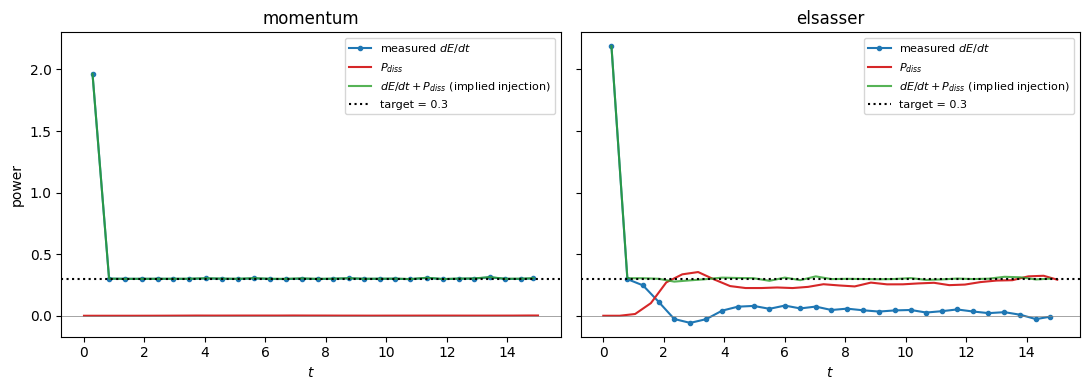

In [8]:
target = 0.3  #momentum: forcing_power; elsasser: eps_plus + eps_minus
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (ts, E_kin, E_mag, P_diss), label in zip(axes, [series_m, series_e],
                                                 ["momentum", "elsasser"]):
    E_tot = E_kin + E_mag
    t_mid = 0.5 * (ts[1:] + ts[:-1])
    dEdt = np.diff(E_tot) / np.diff(ts)
    ax.plot(t_mid, dEdt, marker='o', markersize=3, label=r'measured $dE/dt$')
    ax.plot(ts, P_diss, color='C3', label=r'$P_{diss}$')
    ax.plot(t_mid, dEdt + 0.5 * (P_diss[1:] + P_diss[:-1]), color='C2', alpha=0.8,
            label=r'$dE/dt + P_{diss}$ (implied injection)')
    ax.axhline(target, color='k', linestyle=':', label=f'target = {target}')
    ax.axhline(0.0, color='gray', linewidth=0.5)
    ax.set_xlabel(r'$t$')
    ax.set_title(label)
    ax.legend(fontsize=8)
axes[0].set_ylabel('power')
plt.tight_layout()

### What to look for

- **The spin-up burst:** in both runs the first finite-difference point sits far *above*
  the target -- the capped, one-step-lagged normalization can't control the first big
  coherent kick out of quiescence (discussed above). From the second snapshot on, the
  implied injection (green) locks onto 0.3.
- **Momentum run:** after the burst, the measured $dE/dt$ sits at 0.300 to within the
  finite-difference noise and $P_{\rm diss}$ stays negligible. That is 2D *hydro*
  physics: energy inverse-cascades away from the (large-scale) forcing shell toward even
  larger scales, so the small-scale hyperviscous sink never sees it, and $E$ just grows
  linearly at exactly the target rate.
- **Elsasser run:** injection is the same 0.3, but the MHD run direct-cascades energy to
  small scales, so $P_{\rm diss}$ (red) climbs toward the target and the measured
  $dE/dt$ (blue) sags toward zero: injection $\approx$ dissipation, a developing
  quasi-steady turbulent state. (The snapshot-to-snapshot scatter is the stochastic
  forcing, not an error.)

Things to try: unequal `forcing_power_elsasser` (net cross-helicity injection and
dynamic alignment); moving `fshell` to smaller scales; comparing the spectra of the two
runs with `diag.perpspec`.